In [ ]:
import pandas as pd
import numpy as np

#visualization
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

#Linear Regression
from scipy.stats import linregress

#Train_test_split
from sklearn.model_selection import train_test_split

#cross_val_score
from sklearn.model_selection import cross_val_score

#scaling
from sklearn.preprocessing import StandardScaler



from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score,recall_score, confusion_matrix, classification_report,accuracy_score, f1_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
#models

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

#score
from sklearn.metrics import r2_score


In [ ]:
df = pd.read_csv("/content/insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


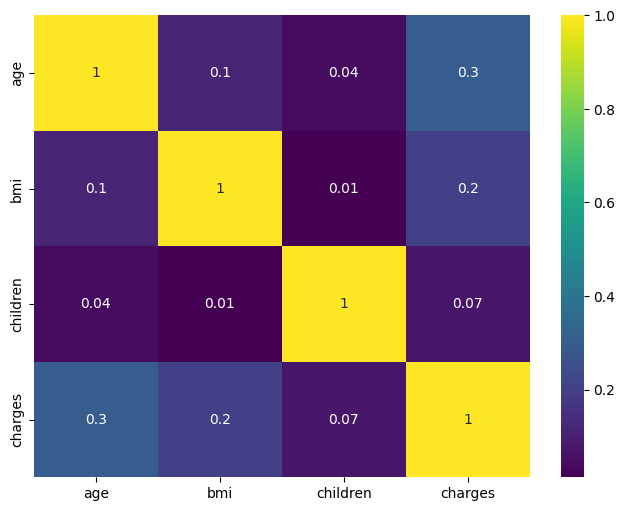

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True),annot=True, fmt='.1g',cmap="viridis",cbar=True,
    ax=ax
)

plt.show()


In [ ]:
df.isnull().any()

,0
age,False
sex,False
bmi,False
children,False
smoker,False
region,False
charges,False


<Axes: ylabel='bmi'>

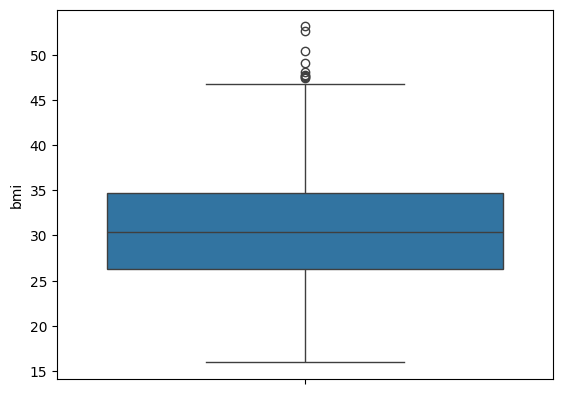

In [ ]:
sns.boxplot(df['bmi'])

In [ ]:
Q1 = df.bmi.quantile(0.25)
Q3 = df.bmi.quantile(0.75)
Q1, Q3

(np.float64(26.29625), np.float64(34.69375))

In [ ]:
IQR = Q3 - Q1
IQR

np.float64(8.3975)

In [ ]:
lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5*IQR
lower_limit, upper_limit

(np.float64(13.7), np.float64(47.290000000000006))

In [ ]:
df[df['bmi'] > upper_limit]

,age,sex,bmi,children,smoker,region,charges
116,58,male,49.06,0,no,southeast,11381.32540
286,46,female,48.07,2,no,northeast,9432.92530
401,47,male,47.52,1,no,southeast,8083.91980
543,54,female,47.41,0,yes,southeast,63770.42801
847,23,male,50.38,1,no,southeast,2438.05520
860,37,female,47.60,2,yes,southwest,46113.51100
1047,22,male,52.58,1,yes,southeast,44501.39820
1088,52,male,47.74,1,no,southeast,9748.91060
1317,18,male,53.13,0,no,southeast,1163.46270


In [ ]:
df_new = df.drop(df.index[[116,401,286,543,847,860,1047,1088,1317]])

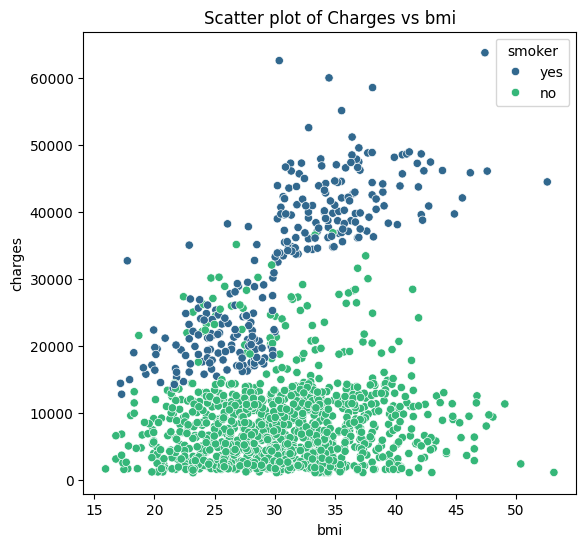

In [ ]:
f = plt.figure(figsize=(14,6))
ax = f.add_subplot(122)
sns.scatterplot(x='bmi',y='charges',data=df,palette='viridis',hue='smoker')
ax.set_title('Scatter plot of Charges vs bmi')
plt.savefig('sc.png');

In [ ]:
df["bmi"].value_counts()

,count
bmi,
32.300,13
28.310,9
30.800,8
31.350,8
30.495,8
...,...
39.425,1
40.480,1
38.900,1


In [ ]:
df['weight_condition'] = np.nan
data = [df]

for col in data:
    col.loc[col.bmi < 18.5, "weight_condition"] = "Underweight"
    col.loc[(col.bmi >= 18.5) & (col.bmi < 24.986), "weight_condition"] = "Normal"
    col.loc[(col.bmi >= 25) & (col.bmi < 29.926), "weight_condition"] = "Overweight"
    col.loc[col.bmi >= 30, "weight_condition"] = "Obese"


/tmp/ipython-input-868920872.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Underweight' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  col.loc[col.bmi < 18.5, "weight_condition"] = "Underweight"


In [ ]:
print(data)

[      age     sex     bmi  children smoker     region      charges  \
0      19  female  27.900         0    yes  southwest  16884.92400   
1      18    male  33.770         1     no  southeast   1725.55230   
2      28    male  33.000         3     no  southeast   4449.46200   
3      33    male  22.705         0     no  northwest  21984.47061   
4      32    male  28.880         0     no  northwest   3866.85520   
...   ...     ...     ...       ...    ...        ...          ...   
1333   50    male  30.970         3     no  northwest  10600.54830   
1334   18  female  31.920         0     no  northeast   2205.98080   
1335   18  female  36.850         0     no  southeast   1629.83350   
1336   21  female  25.800         0     no  southwest   2007.94500   
1337   61  female  29.070         0    yes  northwest  29141.36030   

     weight_condition  
0          Overweight  
1               Obese  
2               Obese  
3              Normal  
4          Overweight  
...           

In [ ]:
df.drop("bmi", axis = 1, inplace = True)
display(df.head())

,age,sex,children,smoker,region,charges,weight_condition
0,19,female,0,yes,southwest,16884.92400,Overweight
1,18,male,1,no,southeast,1725.55230,Obese
2,28,male,3,no,southeast,4449.46200,Obese
3,33,male,0,no,northwest,21984.47061,Normal
4,32,male,0,no,northwest,3866.85520,Overweight


Text(0.5, 1.0, 'Scatter plot of Charges vs age')

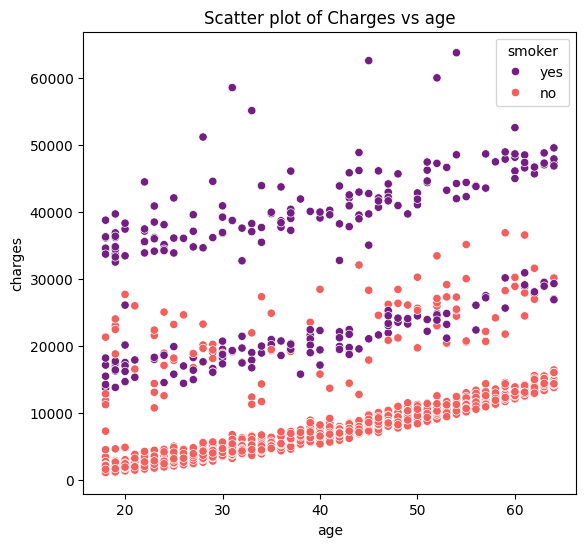

In [ ]:
f = plt.figure(figsize=(14,6))
ax = f.add_subplot(121)
sns.scatterplot(x='age',y='charges',data=df,palette='magma',hue='smoker',ax=ax)
ax.set_title('Scatter plot of Charges vs age')

In [ ]:
df['age_cat'] = np.nan
lst = [df]

for col in lst:
    col.loc[(col['age'] >= 18) & (col['age'] <= 35), 'age_cat'] = 'Young Adult'
    col.loc[(col['age'] > 35) & (col['age'] <= 55), 'age_cat'] = 'Senior Adult'
    col.loc[col['age'] > 55, 'age_cat'] = 'Elder'


/tmp/ipython-input-132442476.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Young Adult' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  col.loc[(col['age'] >= 18) & (col['age'] <= 35), 'age_cat'] = 'Young Adult'


In [ ]:
df.drop("age", axis = 1, inplace = True)
df.head()

,sex,children,smoker,region,charges,weight_condition,age_cat
0,female,0,yes,southwest,16884.92400,Overweight,Young Adult
1,male,1,no,southeast,1725.55230,Obese,Young Adult
2,male,3,no,southeast,4449.46200,Obese,Young Adult
3,male,0,no,northwest,21984.47061,Normal,Young Adult
4,male,0,no,northwest,3866.85520,Overweight,Young Adult


In [ ]:
plt.style.use("seaborn")
fig, ax = plt.subplots(figsize=(5,5))
plt.pie(x=df["sex"].value_counts(),
        colors=["skyblue","pink"],
        labels=["Male","Female"],
        shadow = True,
        autopct="%1.2f%%",
        explode = (0, 0.1)
        )
plt.show()

OSError: 'seaborn' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  func(*plot_args, **plot_kwargs)


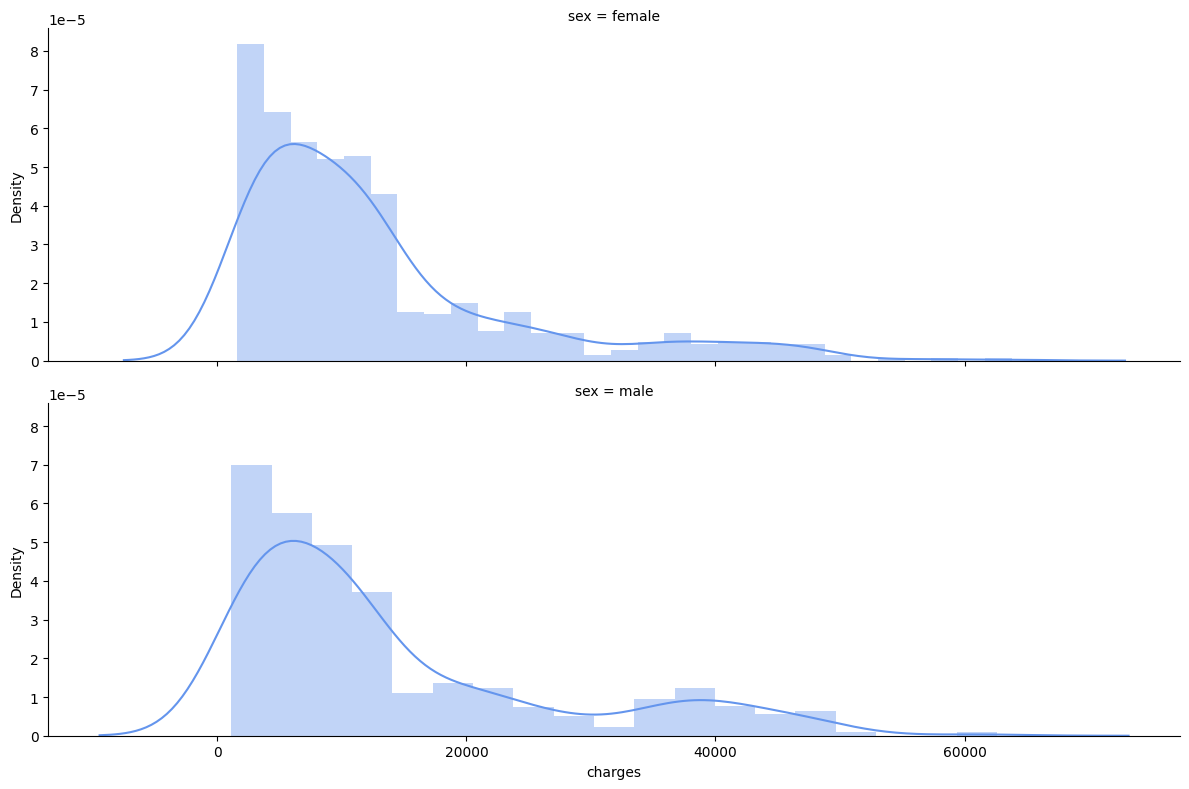

In [ ]:
#Cheking the charges distributions for males and females
x1 = sns.FacetGrid(df, row='sex', height=4, aspect=3)
x1 = x1.map(sns.distplot, 'charges', color='cornflowerblue')
plt.show()

In [ ]:
plt.style.use("seaborn")
fig, ax = plt.subplots(figsize=(6,6))
sns.countplot(df["children"], palette="hls");

OSError: 'seaborn' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)

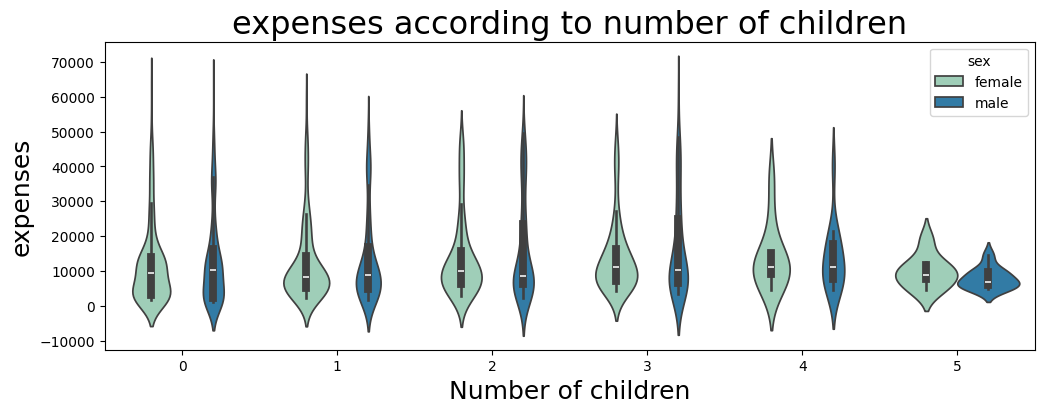

In [ ]:
#Creating a violinplot for each category
plt.figure(figsize=(12,4))
sns.violinplot(x='children', y='charges', data=df, hue='sex', palette='YlGnBu')
plt.title('expenses according to number of children', size='23')
plt.ylabel('expenses',size=18)
plt.xlabel('Number of children',size=18)
plt.show()

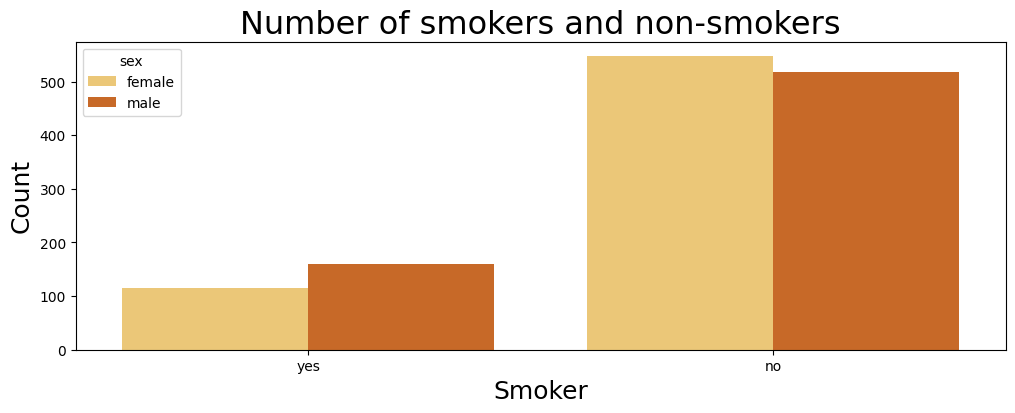

In [ ]:
#Countplot to compare the number of smokers and non-smokers
plt.figure(figsize=(12,4))
sns.countplot(x='smoker', data=df, hue='sex', palette='YlOrBr')
plt.title('Number of smokers and non-smokers', size='23')
plt.ylabel('Count',size=18)
plt.xlabel('Smoker',size=18)
plt.show()


/tmp/ipython-input-4115764356.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='region', data=df, palette='husl')


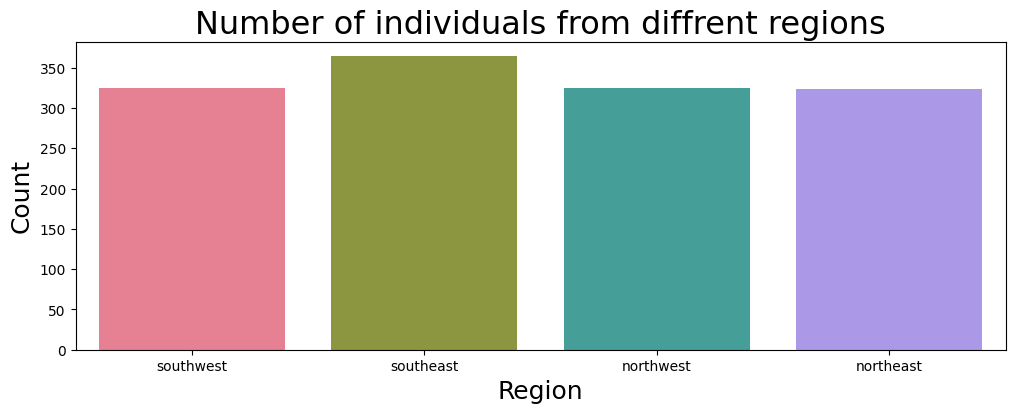

In [ ]:
#Countplot to compare the number of individuals from diffrent regions
plt.figure(figsize=(12,4))
sns.countplot(x='region', data=df, palette='husl')
plt.title('Number of individuals from diffrent regions', size='23')
plt.ylabel('Count',size=18)
plt.xlabel('Region',size=18)
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
les = {}
for col in ['sex','smoker','region', 'weight_condition', 'age_cat']:
    les[col] = LabelEncoder()
    df[col]  = les[col].fit_transform(df[col])

In [ ]:
df.head()

,sex,children,smoker,region,charges,weight_condition,age_cat
0,0,0,1,3,16884.92400,2,2
1,1,1,0,2,1725.55230,1,2
2,1,3,0,2,4449.46200,1,2
3,1,0,0,1,21984.47061,0,2
4,1,0,0,1,3866.85520,2,2


In [ ]:
x= df.drop('charges',axis=1).values
y =df.charges.values
x_tr,x_tst,y_tr,y_tst = train_test_split(x,y,test_size=.2,random_state=2)


In [ ]:
sc = StandardScaler()
x_tr = sc.fit_transform(x_tr)
x_tst = sc.transform(x_tst)

In [ ]:
!pip install catboost

In [ ]:
from catboost import CatBoostRegressor

lr  = LinearRegression()
knn = KNeighborsRegressor(n_neighbors=10)
dt  = DecisionTreeRegressor(max_depth = 3)
rf  = RandomForestRegressor(max_depth = 3, n_estimators=500)
ada = AdaBoostRegressor( n_estimators=50, learning_rate =.01)
gbr = GradientBoostingRegressor(max_depth=2, n_estimators=100, learning_rate =.2)
xgb = XGBRegressor(max_depth = 3, n_estimators=50, learning_rate =.2)
cb  = CatBoostRegressor(learning_rate =.01, max_depth =5, verbose = 0)

regressors = [('Linear Regression', lr), ('K Nearest Neighbours', knn),('Decision Tree', dt), ('Random Forest', rf),
              ('AdaBoost', ada),('Gradient Boosting Regressor', gbr),('XGBRegressor', xgb),('CatBoostRegressor', cb)]


Linear Regression : 71 %
K Nearest Neighbours : 77 %
Decision Tree : 84 %
Random Forest : 84 %
AdaBoost : 84 %
Gradient Boosting Regressor : 85 %
XGBRegressor : 85 %
CatBoostRegressor : 84 %


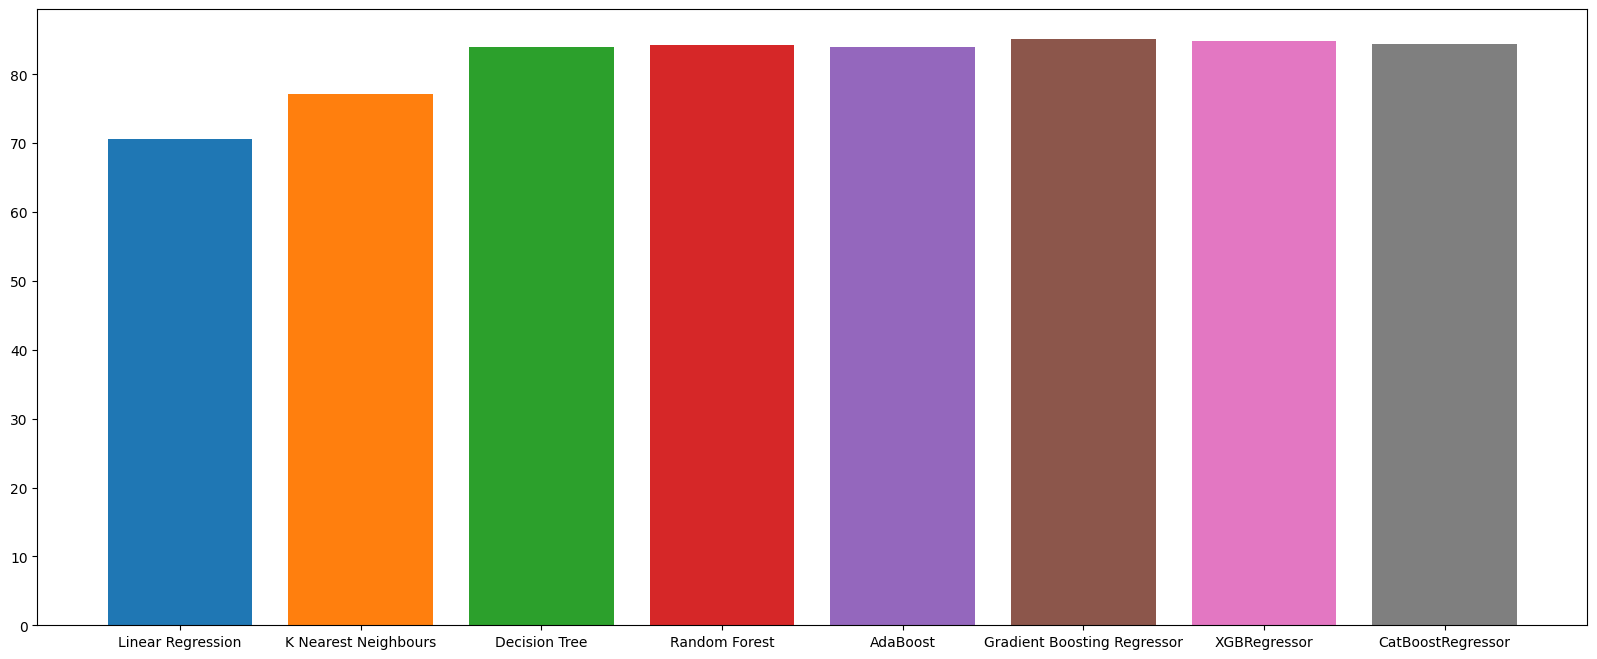

In [ ]:
for regressor_name, regressor in regressors:

    regressor.fit(x_tr, y_tr)

    y_pred = regressor.predict(x_tst)
    accuracy = round(r2_score(y_tst,y_pred),3)*100

    print('{:s} : {:.0f} %'.format(regressor_name, accuracy))
    plt.rcParams["figure.figsize"] = (20,8)
    plt.bar(regressor_name,accuracy)

In [ ]:
y_predict = gbr.predict(x_tst)
gbr_r2_score = r2_score(y_tst, y_predict)
print('R square Score = ', round(gbr_r2_score, 5))

mse = mean_squared_error(y_tst, y_predict)
rmse_1 = np.sqrt(mse)
print('Root Mean Squared Error = ', round(rmse_1,5))


In [ ]:
y_predict = xgb.predict(x_tst)
xgb_r2_score = r2_score(y_tst, y_predict)
print('R square Score = ', round(xgb_r2_score, 5))

mse = mean_squared_error(y_tst, y_predict)
rmse_2 = np.sqrt(mse)
print('Root Mean Squared Error = ', round(rmse_2, 5))


R square Score =  0.84798
Root Mean Squared Error =  4778.12277


In [ ]:
y_predict = cb.predict(x_tst)
cb_r2_score = r2_score(y_tst, y_predict)
print('R square Score = ', round(cb_r2_score, 5))

mse = mean_squared_error(y_tst, y_predict)
rmse_3 = np.sqrt(mse)
print('Root Mean Squared Error = ', round(rmse_3, 5))

R square Score =  0.84449
Root Mean Squared Error =  4832.73088


In [ ]:
score = cross_val_score(xgb, x, y, cv=5)
print(score)

[0.85727576 0.79053102 0.85711183 0.83146259 0.86410448]


In [ ]:
r2_scores = [gbr_r2_score*1000,xgb_r2_score*1000,cb_r2_score*1000]
model_names = ["Gradient Boosting R","XGBRegressor","CatBoostRegresso"]

total_bar = np.arange(len(model_names))
color = ['#9edd1d', '#3edd1d', '#f7c851']

fig, ax = plt.subplots(figsize=(15, 5))
bar = plt.bar(model_names, r2_scores, alpha=1,color=color)
plt.xticks(total_bar, model_names)
plt.ylabel('Accuracy',fontsize=15, color='black')
plt.xlabel('Model Name',fontsize=15, color='black')
plt.title('Model Performance Comparison', fontsize=16, color='black', fontweight='bold')

def autolabel(bar):
    for bar in bar:
        height = int(bar.get_height())
        ax.text(bar.get_x() + .4, .5*height,
                height, va='bottom',
                fontsize=14, color='black')

autolabel(bar)

plt.show()

In [ ]:
m = [rmse_1,rmse_2,rmse_3]
model_names = ["Gradient Boosting R","XGBRegressor","CatBoostRegresso"]

total_bar = np.arange(len(model_names))
color = ['#9edd1d', '#3edd1d', '#f7c851']

fig, ax = plt.subplots(figsize=(15, 5))
bar = plt.bar(model_names, m, alpha=1,color=color)
plt.xticks(total_bar, model_names)
plt.ylabel('Accuracy',fontsize=15, color='black')
plt.xlabel('Model Name',fontsize=15, color='black')
plt.title('Root Mean Squared Error', fontsize=16, color='black', fontweight='bold')

def autolabel(bar):
    for bar in bar:
        height = int(bar.get_height())
        ax.text(bar.get_x() + .4, .5*height,
                height, va='bottom',
                fontsize=14, color='black')

autolabel(bar)

plt.show()